<div style="text-align: center">
    <h2><font size=6>MODELO 2 - RESNET-50 FINETUNNING</font></h2>
</d>
</div>

**Generadores de preprocessing son los mismos que ResNet50**

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    "dataset_final/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

valid_generator = valid_datagen.flow_from_directory(
    "dataset_final/validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    "dataset_final/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(train_generator.class_indices.keys())

Found 4455 images belonging to 6 classes.
Found 952 images belonging to 6 classes.
Found 959 images belonging to 6 classes.


In [14]:
print("Número total de capas:", len(model.layers))

Número total de capas: 179


Congelar las primeras capas y descongelar las últimas

In [17]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [18]:
for layer in model.layers[:140]:
    layer.trainable = False

for layer in model.layers[140:]:
    layer.trainable = True

Recompilar el modelo

In [19]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history_finetune = model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator
)

Epoch 1/20


C:\Users\Usuario\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


140/140 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.7280 - loss: 1.0780 - val_accuracy: 0.8403 - val_loss: 0.5214
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.8316 - loss: 0.5002 - val_accuracy: 0.8550 - val_loss: 0.4871
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.8639 - loss: 0.3935 - val_accuracy: 0.8561 - val_loss: 0.4634
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8735 - loss: 0.3640 - val_accuracy: 0.8571 - val_loss: 0.4311
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.8882 - loss: 0.3155 - val_accuracy: 0.8655 - val_loss: 0.4246
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.9082 - loss: 0.2674 - val_accuracy: 0.8676 - val_loss: 0.4114
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.9074 - loss: 0.2480 - val_accuracy: 0.8697 - val_loss: 0.4174
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.9189 - loss: 0.2206 - val_accuracy: 0.878

In [21]:
val_loss, val_accuracy = model.evaluate(valid_generator, verbose=1)

print(f"Loss en validación: {val_loss}")
print(f"Precisión en validación: {val_accuracy}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9096 - loss: 0.4212
Loss en validación: 0.43133318424224854
Precisión en validación: 0.8981092572212219


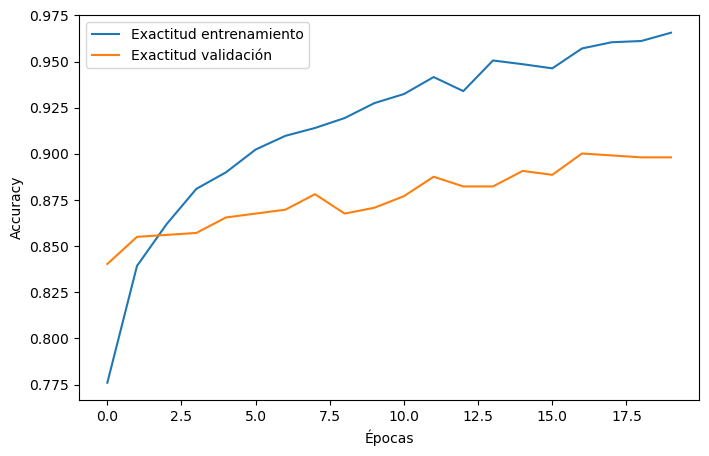

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history_finetune.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(history_finetune.history['val_accuracy'], label='Exactitud validación')

plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [23]:
model.save("modelo_resnet50_finetuned.h5")

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [25]:
model = load_model("modelo_resnet50_finetuned.h5")

In [26]:
test_generator.reset()

In [27]:
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(test_generator.class_indices)

30/30 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step
{'AgeDegeneration': 0, 'Myopia': 1, 'cataract': 2, 'diabetic_retinopathy': 3, 'glaucoma': 4, 'healthy': 5}


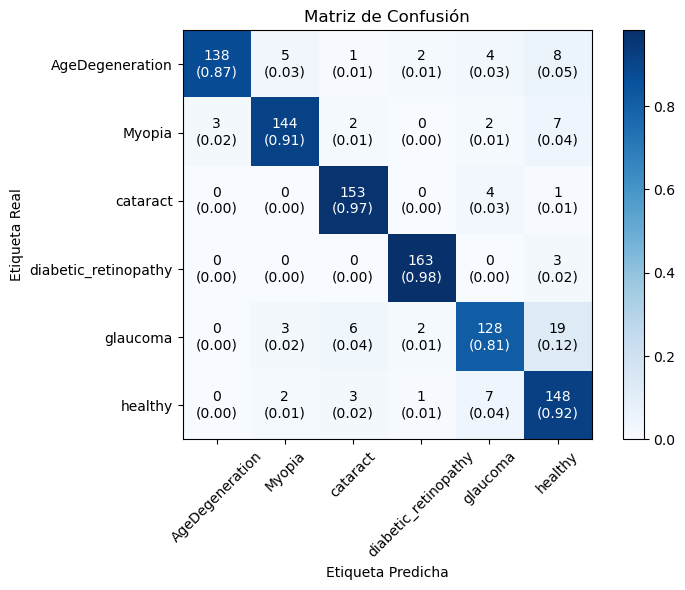

In [28]:
conf_matrix = confusion_matrix(true_classes, predicted_classes)

conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
plt.imshow(conf_matrix_normalized, interpolation='nearest', cmap=plt.cm.Blues)

plt.title("Matriz de Confusión")
plt.colorbar()

tick_marks = np.arange(len(class_labels))

plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

thresh = conf_matrix_normalized.max() / 2.

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):

        absolute_value = conf_matrix[i, j]
        percentage_value = conf_matrix_normalized[i, j]

        plt.text(j, i,
                 f"{absolute_value}\n({percentage_value:.2f})",
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if percentage_value > thresh else "black")

plt.ylabel("Etiqueta Real")
plt.xlabel("Etiqueta Predicha")

plt.tight_layout()
plt.show()

In [29]:
print("Reporte de Clasificación:")

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

Reporte de Clasificación:
                      precision    recall  f1-score   support

     AgeDegeneration       0.98      0.87      0.92       158
              Myopia       0.94      0.91      0.92       158
            cataract       0.93      0.97      0.95       158
diabetic_retinopathy       0.97      0.98      0.98       166
            glaucoma       0.88      0.81      0.84       158
             healthy       0.80      0.92      0.85       161

            accuracy                           0.91       959
           macro avg       0.91      0.91      0.91       959
        weighted avg       0.92      0.91      0.91       959



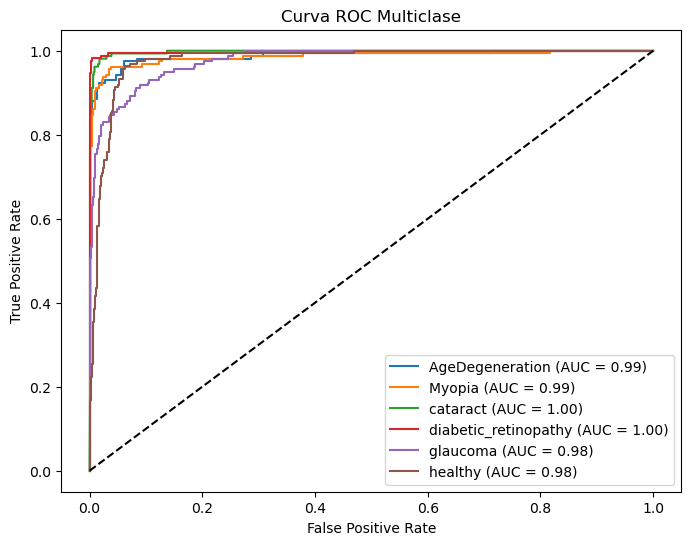

In [30]:
y_true_bin = label_binarize(true_classes, classes=range(len(class_labels)))

plt.figure(figsize=(8,6))

for i in range(len(class_labels)):

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], predictions[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Curva ROC Multiclase")

plt.legend()

plt.show()

In [31]:
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"Loss en test: {test_loss}")
print(f"Precisión en test: {test_accuracy}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8960 - loss: 0.5649
Loss en test: 0.4280683994293213
Precisión en test: 0.9113659858703613


In [32]:
model.save("modelo1_resnet50_final.h5")